# Cascade nucleon and charge conservation

This notebook illustrates the physics behind `TestCascadeNucleonConservation` in `tests/test_crisp.py` and `test_light_secondaries_rate_matches_cumulative_emission` in `tests/test_consolidation.py`.

Two complementary conservation tests are performed:

**Static (rate-matrix level)** - without evolving anything, the interaction tensor `M` and light-yield tensor `Y` must satisfy:
$$\sum_j A_j\, M[i,j,b] + \sum_l A_l\sum_j Y[l,i,j,b] = 0 \quad \forall\; i, b$$

This says: no nucleons are created or destroyed by any single channel at any boost.

**Dynamic (propagation level)** - the full nucleon count
$$A_{\rm total}(L) = \sum_i A_i\, P_i^{\rm heavy}(L) + \sum_l A_l\, N_l^{\rm light}(L) + 1 \cdot |P_{\rm abs}(L)|$$
must equal $A_{\rm injection}$ at every distance $L$ and every boost.  The evolution is computed with the existing `species_evolution_boost_range` and `light_cascade_production` methods, which work simultaneously over the full requested boost range.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from crisp.core import InteractionCore
from crisp.photonuclear_cross_sections import PSB_model

psb = InteractionCore(xsec_model=PSB_model())

species = psb.species
A_sp    = np.array([s[1] for s in species], dtype=float)
Z_sp    = np.array([s[0] for s in species], dtype=float)

# Light-species properties: [He4, He3, H3, H2, p, n]
A_light = np.array([4., 3., 3., 2., 1., 1.])
Z_light = np.array([2., 2., 1., 1., 1., 0.])

print(f"Species tracked: {len(species)}  ({species[0]} … {species[-1]})")
print(f"Boost grid: {psb.boosts[0]:.1e} – {psb.boosts[-1]:.1e}  ({len(psb.boosts)} points)")

Species tracked: 53  ((26, 56) … (1, 1))
Boost grid: 1.0e+06 – 1.0e+14  (201 points)


## 1. Static conservation check

For each parent species $i$ and boost $b$, the A-weighted row sum of the full rate matrix must be zero.

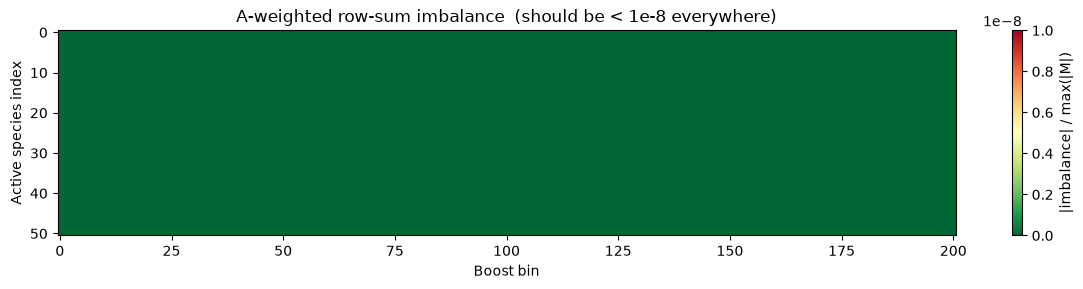

Maximum relative imbalance: 2.26e-14  (test tolerance: 1e-8)
Static nucleon conservation: PASSED


In [2]:
M = psb.tensor            # (n_sp, n_sp, n_boosts)
Y = psb.light_prod_tensor  # (6, n_sp, n_sp, n_boosts)

# A-weighted row sums
heavy_flow = np.einsum('j,ijb->ib', A_sp, M)
light_flow = np.einsum('l,lijb->ib', A_light, Y)
imbalance  = heavy_flow + light_flow

active = np.any(np.abs(M) > 0, axis=(1, 2))
scale  = np.abs(M).max()

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(np.abs(imbalance[active]) / scale, aspect='auto', cmap='RdYlGn_r',
               vmin=0, vmax=1e-8)
plt.colorbar(im, ax=ax, label='|imbalance| / max(|M|)')
ax.set_xlabel('Boost bin')
ax.set_ylabel('Active species index')
ax.set_title('A-weighted row-sum imbalance  (should be < 1e-8 everywhere)')
plt.tight_layout()
plt.show()

max_imbalance = np.abs(imbalance[active]).max() / scale
print(f"Maximum relative imbalance: {max_imbalance:.2e}  (test tolerance: 1e-8)")
assert max_imbalance < 1e-8
print("Static nucleon conservation: PASSED")

## 2. Setup: Fe-56 injection and boost / distance grids

`get_distribution_parameters` prepares the injection vector and species index lists accepted by the propagation methods.

In [3]:
alpha, mr, tr, _ = psb.get_distribution_parameters(
    mass_lims=(56, 0),
    injection_type=('only species', (26, 56)),
    absorption_type=('only mass', [1]),   # A=1 (p, n) are the endpoint
)

# Boost range spanning the full photodisintegration-active window.
# Conservation holds at machine precision for any sub-range of the grid.
boost_range = psb.boosts[80:120]

# Propagation distances
L_vals = np.concatenate([np.linspace(0, 10, 40), np.linspace(10, 500, 60)[1:]])

A_tr    = A_sp[[mr.index(v) for v in tr]]

print(f"Injection vector sums to: {alpha.sum():.3f}")
print(f"mass_range: {len(mr)} species, true_range: {len(tr)} non-absorbed species")
print(f"Boost range: {boost_range[0]:.2e} – {boost_range[-1]:.2e}  ({len(boost_range)} boosts)")
print(f"Distance range: {L_vals[0]:.1f} – {L_vals[-1]:.0f} Mpc  ({len(L_vals)} points)")

Injection vector sums to: 1.000
mass_range: 53 species, true_range: 51 non-absorbed species
Boost range: 1.58e+09 – 5.75e+10  (40 boosts)
Distance range: 0.0 – 500 Mpc  (99 points)


## 3. Dynamic nucleon conservation

We use the existing class methods to evolve the heavy and light populations jointly over the requested boost range and all distances in a single call:

- `species_evolution_boost_range` → heavy species probabilities + absorbed sink
- `light_cascade_production` → cumulative light-particle yields

The returned arrays span all requested boosts and distances; no matrix exponentials are written by hand.

In [4]:
# Heavy species evolution: shape (n_b, n_L, n_tr + 1)
# Last column is the absorbed-probability sink (stored with inverted sign).
heavy_aug = psb.species_evolution_boost_range(L_vals, alpha, mr, boost_range, tr)

# Light cascade: shape (6, n_b, n_L)
light_out = psb.light_cascade_production(
    L_vals, alpha, mass_range=mr, boost_range=boost_range, true_range=tr
)

print(f"heavy_aug shape: {heavy_aug.shape}  (n_b, n_L, n_tr+1)")
print(f"light_out shape: {light_out.shape}  (6, n_b, n_L)")

heavy_aug shape: (40, 99, 52)  (n_b, n_L, n_tr+1)
light_out shape: (6, 40, 99)  (6, n_b, n_L)


In [5]:
# Three-way balance: A_tr·P_heavy + A_light·N_light + 1·|P_abs| should equal 56.
# heavy_aug[b, l, :-1] = P_heavy; heavy_aug[b, l, -1] = -P_abs (sign convention)

A_heavy_sum = np.einsum('i,bli->bl', A_tr, heavy_aug[:, :, :-1])    # (n_b, n_L)
A_light_sum = np.einsum('l,lbi->bi', A_light, light_out)             # (n_b, n_L)
P_abs       = -heavy_aug[:, :, -1]                                   # (n_b, n_L)

nucleon_total = A_heavy_sum + A_light_sum + P_abs  # should be 56 everywhere
A_inj = 56.0

residual = np.abs(nucleon_total - A_inj)  # (n_b, n_L)

print("Three-way balance (A_heavy + A_light + A_absorbed = 56):")
print(f"  Max absolute residual across all boosts and distances: {residual.max():.2e}")
print(f"  Max relative residual: {(residual / A_inj).max():.2e}  (machine precision ~1e-10)")
assert (residual / A_inj).max() < 1e-8
print("Dynamic nucleon conservation: PASSED")

Three-way balance (A_heavy + A_light + A_absorbed = 56):
  Max absolute residual across all boosts and distances: 1.65e-12
  Max relative residual: 2.94e-14  (machine precision ~1e-10)
Dynamic nucleon conservation: PASSED


## 4. Boost range scan

The three-way balance holds at machine precision for any sub-range of the boost grid - there is no threshold below which conservation degrades.  The cell below sweeps the minimum boost index and records the maximum relative residual.

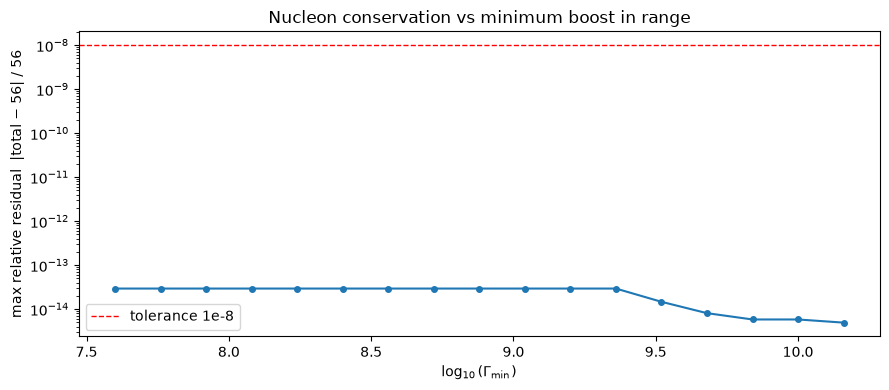

Max residual across all tested ranges: 2.94e-14


In [6]:
min_indices = range(40, 106, 4)
max_rels = []
gmin_vals = []

for mi in min_indices:
    br = psb.boosts[mi:120]
    H  = psb.species_evolution_boost_range(L_vals, alpha, mr, br, tr)
    N  = psb.light_cascade_production(L_vals, alpha, mass_range=mr, boost_range=br, true_range=tr)
    AH = np.einsum('i,bli->bl', A_tr, H[:, :, :-1])
    AL = np.einsum('l,lbi->bi', A_light, N)
    tot = AH + AL + (-H[:, :, -1])
    max_rels.append(np.abs(tot - A_inj).max() / A_inj)
    gmin_vals.append(br[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(np.log10(gmin_vals), max_rels, 'o-', ms=4)
ax.axhline(1e-8, color='r', ls='--', lw=1, label='tolerance 1e-8')
ax.set_xlabel(r'$\log_{10}(\Gamma_{\min})$')
ax.set_ylabel('max relative residual  |total − 56| / 56')
ax.set_title('Nucleon conservation vs minimum boost in range')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Max residual across all tested ranges: {max(max_rels):.2e}")

## 5. Nucleon budget vs propagation distance

We plot the three budget components for the central boost in the range.

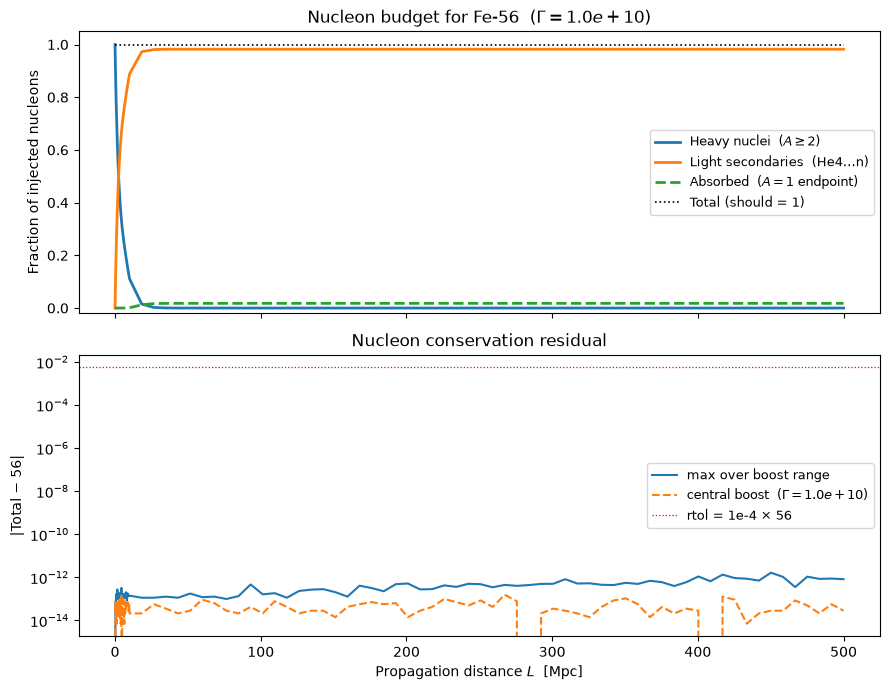

In [7]:
bi = len(boost_range) // 2   # central boost index
gamma_label = f"$\\Gamma = {boost_range[bi]:.1e}$"

A_ph = A_heavy_sum[bi]
A_nl = A_light_sum[bi]
A_ab = P_abs[bi]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(L_vals, A_ph / A_inj, lw=2, label='Heavy nuclei  ($A \\geq 2$)')
ax1.plot(L_vals, A_nl / A_inj, lw=2, label='Light secondaries  (He4…n)')
ax1.plot(L_vals, A_ab / A_inj, lw=2, ls='--', label='Absorbed  ($A=1$ endpoint)')
ax1.plot(L_vals, (A_ph + A_nl + A_ab) / A_inj, 'k:', lw=1.2, label='Total (should = 1)')
ax1.set_ylabel('Fraction of injected nucleons')
ax1.set_title(f'Nucleon budget for Fe-56  ({gamma_label})', fontsize=12)
ax1.legend(fontsize=9)
ax1.set_ylim(-0.02, 1.05)

# Conservation residual across all boosts
ax2.semilogy(L_vals, residual.max(axis=0), label='max over boost range')
ax2.semilogy(L_vals, residual[bi],         label=f'central boost  ({gamma_label})', ls='--')
ax2.axhline(A_inj * 1e-4, color='r', ls=':', lw=0.9, label='rtol = 1e-4 × 56')
ax2.set_xlabel('Propagation distance $L$  [Mpc]')
ax2.set_ylabel('|Total − 56|')
ax2.set_title('Nucleon conservation residual')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Species distribution vs distance

While the total nucleon count is conserved, Fe-56 progressively photodisintegrates into lighter nuclei and eventually into free nucleons.

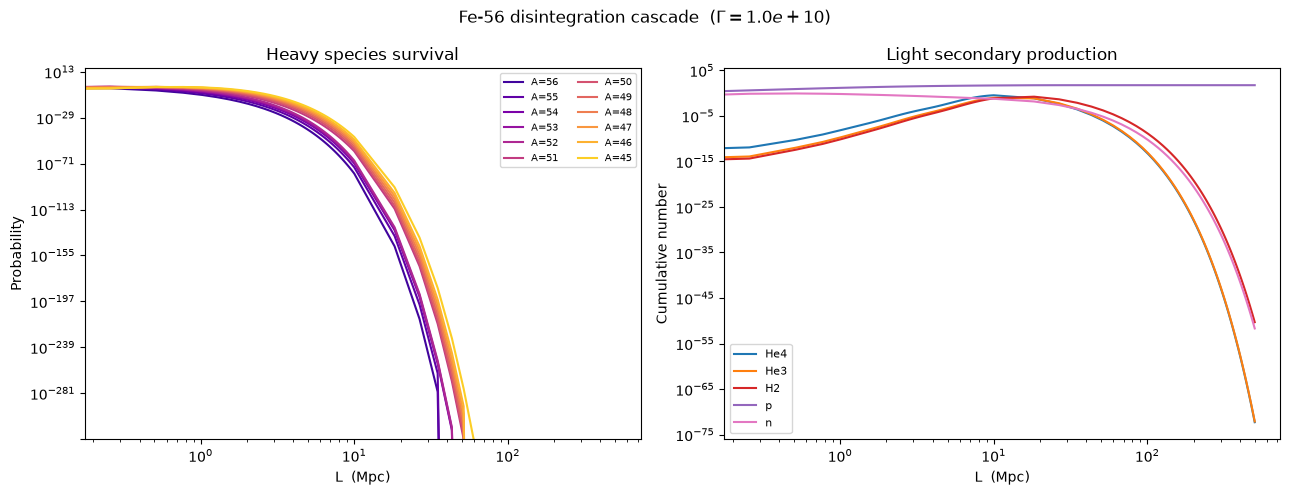

In [8]:
# Group heavy species by mass number for the central boost
species_full = psb.species
P_heavy_full = heavy_aug[bi, :, :-1]   # (n_L, n_tr)

A_group = {}
for sp_local_idx, sp_global_idx in enumerate(tr):
    A_val = species_full[sp_global_idx][1]
    A_group.setdefault(A_val, []).append(sp_local_idx)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cmap = plt.cm.plasma
A_keys = sorted(A_group.keys(), reverse=True)
colors = cmap(np.linspace(0.1, 0.9, min(len(A_keys), 12)))

for col, A_val in zip(colors, A_keys[:12]):
    prob = P_heavy_full[:, A_group[A_val]].sum(axis=1)
    if prob.max() > 1e-4:
        axes[0].loglog(L_vals, prob, color=col, label=f'A={A_val}')

axes[0].set_xlabel('L  (Mpc)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Heavy species survival')
axes[0].legend(fontsize=7, ncol=2)

light_names  = ['He4', 'He3', 'H3', 'H2', 'p', 'n']
light_colors = plt.cm.tab10(np.linspace(0, 0.6, 6))
N_lt = light_out[:, bi, :]   # (6, n_L) for the central boost
for l, (name, col) in enumerate(zip(light_names, light_colors)):
    if N_lt[l].max() > 1e-4:
        axes[1].loglog(L_vals, N_lt[l], color=col, label=name)

axes[1].set_xlabel('L  (Mpc)')
axes[1].set_ylabel('Cumulative number')
axes[1].set_title('Light secondary production')
axes[1].legend(fontsize=8)

plt.suptitle(f'Fe-56 disintegration cascade  ({gamma_label})', fontsize=12)
plt.tight_layout()
plt.show()